# Import Libraries


In [1]:
import pandas as pd
import numpy as np
import torch
from torch.utils.data import TensorDataset, DataLoader, SequentialSampler, WeightedRandomSampler
from torch.nn.utils.rnn import pad_sequence
from sklearn.model_selection import train_test_split
from sklearn.utils.class_weight import compute_class_weight
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, classification_report, confusion_matrix
import random
import os
from tqdm.auto import tqdm
from tqdm import tqdm
import gc
import matplotlib.pyplot as plt
import seaborn as sns
from transformers import BertTokenizer, BertForSequenceClassification, AutoTokenizer, RobertaForSequenceClassification, get_linear_schedule_with_warmup
from torch.optim import AdamW
import torch.nn as nn
import datetime
import shap
from collections import Counter
from sklearn.preprocessing import LabelEncoder

2025-06-05 17:12:41.456457: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:477] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1749143561.968478      35 cuda_dnn.cc:8310] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1749143562.091371      35 cuda_blas.cc:1418] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered


#  Reproducibility

In [2]:
# SET RANDOM SEEDS FOR REPRODUCIBILITY
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)
os.environ['PYTHONHASHSEED'] = str(SEED)
torch.backends.cudnn.deterministic = True

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# Load the dataset


In [3]:
# Load Data
file_path = '/kaggle/input/personal-care/amazon_reviews_us_Personal_Care_Appliances_v1_00.tsv'
df = pd.read_csv(file_path, on_bad_lines='skip', sep='\t')

# Display the shape of the dataset


In [4]:
print(f"Dataset contains {df.shape[0]} rows and {df.shape[1]} columns.\n")

Dataset contains 85924 rows and 15 columns.



# Display the first few rows


In [5]:
print("First 5 rows of the dataset:")
df.head()

First 5 rows of the dataset:


,marketplace,customer_id,review_id,product_id,product_parent,product_title,product_category,star_rating,helpful_votes,total_votes,vine,verified_purchase,review_headline,review_body,review_date
0,US,32114233,R1QX6706ZWJ1P5,B00OYRW4UE,223980852,Elite Sportz Exercise Sliders are Double Sided...,Personal_Care_Appliances,5,0,0,N,Y,Good quality. Shipped,Exactly as described. Good quality. Shipped fast,2015-08-31
1,US,18125776,R3QWMLJHIW6P37,B0000537JQ,819771537,Ezy Dose Weekly,Personal_Care_Appliances,5,0,0,N,Y,Five Stars,It is great,2015-08-31
2,US,19917519,R14Z1VR1N0Z9G6,B00HXXO332,849307176,"Pulse Oximeter, Blood Oxygen Monitor",Personal_Care_Appliances,5,1,1,N,Y,It's really nice it works great,It's really nice it works great. You have the ...,2015-08-31
3,US,18277171,R25ZRJL0GH0U0,B00EOB0JA2,700864740,SE Tools Tool Kit Watch Watch Repair Kit (20 P...,Personal_Care_Appliances,2,0,0,N,Y,Two Stars,The kit works fine... simple cheap plastic tho,2015-08-31
4,US,2593270,R3837KYH7AZNIY,B00OC2O1UC,794298839,"doTERRA HD Clear Facial Kit - Facial Lotion, F...",Personal_Care_Appliances,4,0,1,N,Y,Four Stars,It works better than anything else ive tried,2015-08-31


# Display column names


In [6]:
print("\nColumn names:")
df.columns.tolist()


Column names:


['marketplace',
 'customer_id',
 'review_id',
 'product_id',
 'product_parent',
 'product_title',
 'product_category',
 'star_rating',
 'helpful_votes',
 'total_votes',
 'vine',
 'verified_purchase',
 'review_headline',
 'review_body',
 'review_date']

# Display data types and non-null counts


In [7]:
print("\nDataset info:")
df.info()


Dataset info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 85924 entries, 0 to 85923
Data columns (total 15 columns):
 #   Column             Non-Null Count  Dtype 
---  ------             --------------  ----- 
 0   marketplace        85924 non-null  object
 1   customer_id        85924 non-null  int64 
 2   review_id          85924 non-null  object
 3   product_id         85924 non-null  object
 4   product_parent     85924 non-null  int64 
 5   product_title      85920 non-null  object
 6   product_category   85924 non-null  object
 7   star_rating        85924 non-null  int64 
 8   helpful_votes      85924 non-null  int64 
 9   total_votes        85924 non-null  int64 
 10  vine               85924 non-null  object
 11  verified_purchase  85924 non-null  object
 12  review_headline    85923 non-null  object
 13  review_body        85924 non-null  object
 14  review_date        85924 non-null  object
dtypes: int64(5), object(10)
memory usage: 9.8+ MB


# Display summary statistics for numerical columns


In [8]:
print("\nSummary statistics:")
df.describe()


Summary statistics:


,customer_id,product_parent,star_rating,helpful_votes,total_votes
count,8.592400e+04,8.592400e+04,85924.000000,85924.000000,85924.000000
mean,2.943395e+07,5.138159e+08,3.977236,3.351520,4.061357
std,1.525241e+07,2.919951e+08,1.433323,19.489455,20.832674
min,1.047000e+04,3.573000e+03,1.000000,0.000000,0.000000
25%,1.547730e+07,2.628535e+08,3.000000,0.000000,0.000000
50%,2.903199e+07,4.981086e+08,5.000000,0.000000,1.000000
75%,4.372740e+07,7.899794e+08,5.000000,2.000000,3.000000
max,5.309657e+07,9.999599e+08,5.000000,2785.000000,2876.000000


# Check for missing values


In [9]:
print("\nMissing values per column:")
df.isnull().sum()


Missing values per column:


marketplace          0
customer_id          0
review_id            0
product_id           0
product_parent       0
product_title        4
product_category     0
star_rating          0
helpful_votes        0
total_votes          0
vine                 0
verified_purchase    0
review_headline      1
review_body          0
review_date          0
dtype: int64

# Check rating distribution


 Rating Distribution:


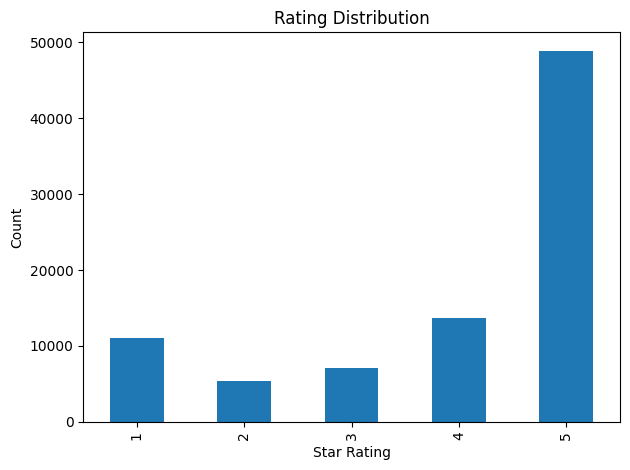

<Figure size 640x480 with 0 Axes>

In [10]:
if 'star_rating' in df.columns:
    print("\n Rating Distribution:")
    df['star_rating'].value_counts().sort_index()

    df['star_rating'].value_counts().sort_index().plot(kind='bar', title='Rating Distribution')
    plt.xlabel('Star Rating')
    plt.ylabel('Count')
    plt.tight_layout()
    plt.show()  
    plt.clf()

# Calculate and plot string length (characters)

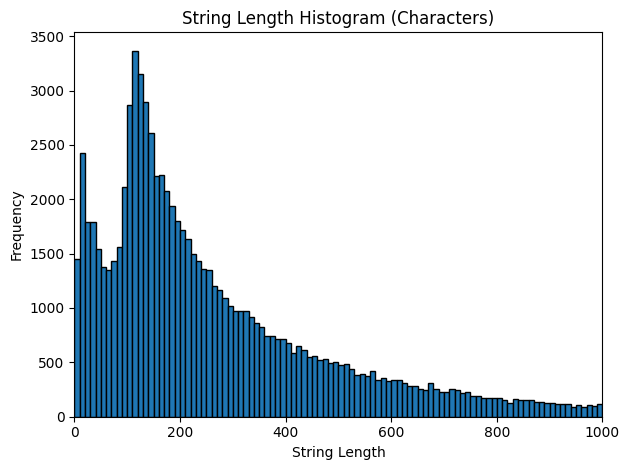

<Figure size 640x480 with 0 Axes>

In [11]:
df['String_Length'] = df['review_body'].astype(str).apply(len)

plt.hist(df['String_Length'], 
         bins=range(0, 1001, 10),  # bin every 10 chars up to 1000
         edgecolor='black')
plt.title('String Length Histogram (Characters)')
plt.xlabel('String Length')
plt.ylabel('Frequency')
plt.xlim(0, 1000)
plt.tight_layout()
plt.show()
plt.clf()

# Calculate and plot word count

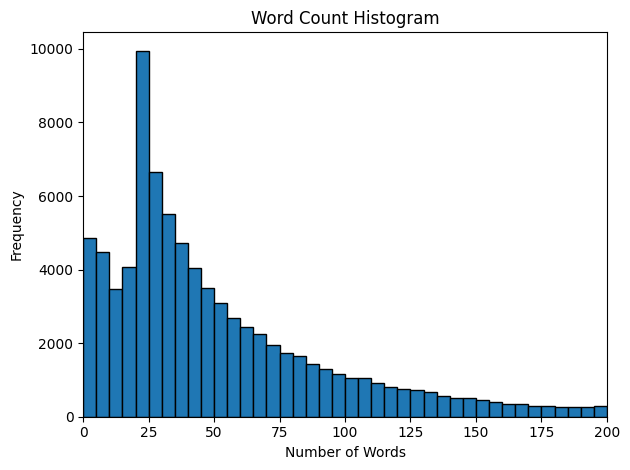

<Figure size 640x480 with 0 Axes>

In [12]:
df['Word_Count'] = df['review_body'].astype(str).apply(lambda x: len(x.split()))

plt.hist(df['Word_Count'], 
         bins=range(0, 201, 5),  # bin every 5 words up to 200
         edgecolor='black')
plt.title('Word Count Histogram')
plt.xlabel('Number of Words')
plt.ylabel('Frequency')
plt.xlim(0, 200)
plt.tight_layout()
plt.show()
plt.clf()

# 1. Data Preprocessing


# Drop rows with missing values


In [13]:
df = df[['star_rating', 'product_title', 'review_headline', 'review_body']].dropna()

# Convert star ratings to sentiment classes (0: Negative, 1: Neutral, 2: Positive)


In [14]:
df['star_rating'] = pd.to_numeric(df['star_rating'], errors='coerce')
df['sentiment'] = df['star_rating'].apply(lambda x: 0 if x <= 3 else 1)

# Combine 3 columns

In [15]:
df['combined_text'] = df['product_title'] + " " + df['review_headline'] + " " + df['review_body']
df['combined_text'] = df['combined_text'].apply(lambda x: ' '.join(x.split()[:128]))
labels = torch.tensor(df['sentiment'].values)

# Print class distribution


In [16]:
# Label mapping for binary classification
label_names = {0: "Negative", 1: "Positive"}

# Count occurrences
class_counts = np.bincount(df['sentiment'])
total_samples = len(df)

print("Class Distribution (Full Dataset):")
for label, count in enumerate(class_counts):
    percentage = count / total_samples * 100
    print(f"{label_names[label]}: {count} samples ({percentage:.2f}%)")


Class Distribution (Full Dataset):
Negative: 23415 samples (27.25%)
Positive: 62504 samples (72.75%)


# View cleaned data

In [17]:
print("\nPreview of Cleaned Data:")
df[['star_rating', 'sentiment', 'combined_text']].sample(10, random_state=42)


Preview of Cleaned Data:


,star_rating,sentiment,combined_text
226,5,1,Viva Naturals #1 Best Selling Certified Organi...
71481,3,0,Clean + Easy Deluxe Home Electrolysis If you h...
72642,5,1,The Acuvibe Wireless Massager Amazing! I first...
11687,1,0,Personal Pedi Water Proof Electronic Hand and ...
71552,5,1,Denman Denman Styling Brush Heavy Weight 9 Row...
37974,5,1,Vktech Replacement Electric Toothbrush Heads P...
58155,4,1,"Lock Laces, Black Good For Those With Little T..."
39741,5,1,Oral-B Power Tip Replacement Electric Toothbru...
28511,2,0,Mega Motion Infinate Position Power Easy Comfo...
48480,5,1,"IQAir Pre-Filter Replacement for HealthPro, He..."


# 2. Tokenize function


In [18]:
# Tokenization
MAX_LEN = 96
BATCH_SIZE = 16
bert_tokenizer = BertTokenizer.from_pretrained('bert-base-uncased')
roberta_tokenizer = AutoTokenizer.from_pretrained('roberta-base')

def tokenize_dataset(texts, tokenizer):
    input_ids, attention_masks = [], []
    for text in tqdm(texts):
        encoded = tokenizer.encode_plus(
            text,
            add_special_tokens=True,
            max_length=MAX_LEN,
            padding='max_length',
            truncation=True,
            return_attention_mask=True,
            return_tensors='pt')
        input_ids.append(encoded['input_ids'].squeeze(0))
        attention_masks.append(encoded['attention_mask'].squeeze(0))
    return torch.stack(input_ids), torch.stack(attention_masks)

bert_ids, bert_masks = tokenize_dataset(df['combined_text'], bert_tokenizer)
roberta_ids, roberta_masks = tokenize_dataset(df['combined_text'], roberta_tokenizer)

tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

vocab.txt:   0%|          | 0.00/232k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/466k [00:00<?, ?B/s]

config.json:   0%|          | 0.00/570 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/25.0 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/481 [00:00<?, ?B/s]

vocab.json:   0%|          | 0.00/899k [00:00<?, ?B/s]

merges.txt:   0%|          | 0.00/456k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/1.36M [00:00<?, ?B/s]

100%|██████████| 85919/85919 [00:41<00:00, 2089.30it/s]


# 3. Dataset splits (80% train, 10% val, 10% test)

In [19]:
# Zipped input-mask pairs for splitting
X_b = list(zip(bert_ids, bert_masks))
X_r = list(zip(roberta_ids, roberta_masks))

# Split
X_temp_b, X_test_b, X_temp_r, X_test_r, y_temp, y_test = train_test_split(
    X_b, X_r, labels, test_size=0.1, stratify=labels, random_state=SEED)
X_train_b, X_val_b, X_train_r, X_val_r, y_train, y_val = train_test_split(
    X_temp_b, X_temp_r, y_temp, test_size=0.1111, stratify=y_temp, random_state=SEED)

# Unpack tensors
X_train_b, train_masks_b = zip(*X_train_b)
X_val_b, val_masks_b = zip(*X_val_b)
X_test_b, test_masks_b = zip(*X_test_b)
X_train_r, train_masks_r = zip(*X_train_r)
X_val_r, val_masks_r = zip(*X_val_r)
X_test_r, test_masks_r = zip(*X_test_r)

# Stack
X_train_b = torch.stack(X_train_b)
val_masks_b = torch.stack(val_masks_b)
X_val_b = torch.stack(X_val_b)
train_masks_b = torch.stack(train_masks_b)
X_test_b = torch.stack(X_test_b)
test_masks_b = torch.stack(test_masks_b)
X_train_r = torch.stack(X_train_r)
train_masks_r = torch.stack(train_masks_r)
X_val_r = torch.stack(X_val_r)
val_masks_r = torch.stack(val_masks_r)
X_test_r = torch.stack(X_test_r)
test_masks_r = torch.stack(test_masks_r)

# 4. Compute class weights


In [20]:
# Class weights
class_weights = compute_class_weight('balanced', classes=np.unique(y_train.numpy()), y=y_train.numpy())
weights_train = torch.tensor([class_weights[label] for label in y_train.numpy()], dtype=torch.float)
train_sampler = WeightedRandomSampler(weights_train, num_samples=len(weights_train), replacement=True)
train_sampler_r = WeightedRandomSampler(weights_train, num_samples=len(weights_train), replacement=True)

# Data Loaders

In [21]:
# === Loaders Already Defined ===
print(f"Total Samples: Train={len(y_train)}, Val={len(y_val)}, Test={len(y_test)}")

train_loader_b = DataLoader(TensorDataset(X_train_b, train_masks_b, y_train), sampler=train_sampler, batch_size=BATCH_SIZE)
val_loader_b = DataLoader(TensorDataset(X_val_b, val_masks_b, y_val), sampler=SequentialSampler(X_val_b), batch_size=BATCH_SIZE)
test_loader_b = DataLoader(TensorDataset(X_test_b, test_masks_b, y_test), sampler=SequentialSampler(X_test_b), batch_size=BATCH_SIZE)

train_loader_r = DataLoader(TensorDataset(X_train_r, train_masks_r, y_train), sampler=train_sampler_r, batch_size=BATCH_SIZE)
val_loader_r = DataLoader(TensorDataset(X_val_r, val_masks_r, y_val), sampler=SequentialSampler(X_val_r), batch_size=BATCH_SIZE)
test_loader_r = DataLoader(TensorDataset(X_test_r, test_masks_r, y_test), sampler=SequentialSampler(X_test_r), batch_size=BATCH_SIZE)


Total Samples: Train=68735, Val=8592, Test=8592


# 5. DEFINE MODELS + TRAINING FUNCTION


In [22]:
EPOCHS = 3

# === Model Training Function ===
def train_model(model, train_loader, val_loader, model_path='model.pt', name='Model'):
    optimizer = AdamW(model.parameters(), lr=5e-6, eps=1e-8, weight_decay=0.1)
    total_steps = len(train_loader) * EPOCHS
    scheduler = get_linear_schedule_with_warmup(optimizer, int(0.1 * total_steps), total_steps)
    best_val_loss = float('inf')
    model.to(device)

    print(f"\nTraining {name} for {EPOCHS} epochs")

    for epoch in range(EPOCHS):
        # === Training ===
        model.train()
        train_loss, train_correct, total_train = 0, 0, 0
        for batch in tqdm(train_loader, desc=f"[{name}] Epoch {epoch+1}/{EPOCHS}"):
            input_ids, masks, labels = [x.to(device) for x in batch]
            model.zero_grad()
            outputs = model(input_ids, attention_mask=masks, labels=labels)
            loss = outputs.loss
            logits = outputs.logits
            loss.backward()
            torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
            optimizer.step()
            scheduler.step()

            train_loss += loss.item()
            preds = torch.argmax(logits, dim=1)
            train_correct += (preds == labels).sum().item()
            total_train += labels.size(0)

        avg_train_loss = train_loss / len(train_loader)
        avg_train_acc = train_correct / total_train

        # === Validation ===
        model.eval()
        val_loss, val_correct, total_val = 0, 0, 0
        for batch in val_loader:
            input_ids, masks, labels = [x.to(device) for x in batch]
            with torch.no_grad():
                outputs = model(input_ids, attention_mask=masks, labels=labels)
                loss = outputs.loss
                logits = outputs.logits

            val_loss += loss.item()
            preds = torch.argmax(logits, dim=1)
            val_correct += (preds == labels).sum().item()
            total_val += labels.size(0)

        avg_val_loss = val_loss / len(val_loader)
        avg_val_acc = val_correct / total_val

        # Print epoch metrics
        print(f"[{name}] Epoch {epoch+1}/{EPOCHS} | "
              f"Train Loss: {avg_train_loss:.4f}, Train Acc: {avg_train_acc:.4f} | "
              f"Val Loss: {avg_val_loss:.4f}, Val Acc: {avg_val_acc:.4f}")

        # Save best model based on validation loss
        if avg_val_loss < best_val_loss:
            best_val_loss = avg_val_loss
            torch.save(model.state_dict(), model_path)

    return model_path

# === Train BERT and RoBERTa ===
bert_model = BertForSequenceClassification.from_pretrained('bert-base-uncased', num_labels=2)
bert_path = train_model(bert_model, train_loader_b, val_loader_b, model_path='bert_best.pt', name='BERT')
del bert_model; gc.collect(); torch.cuda.empty_cache()

roberta_model = RobertaForSequenceClassification.from_pretrained('roberta-base', num_labels=2)
roberta_path = train_model(roberta_model, train_loader_r, val_loader_r, model_path='roberta_best.pt', name='RoBERTa')
del roberta_model; gc.collect(); torch.cuda.empty_cache()


model.safetensors:   0%|          | 0.00/440M [00:00<?, ?B/s]

Some weights of BertForSequenceClassification were not initialized from the model checkpoint at bert-base-uncased and are newly initialized: ['classifier.bias', 'classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.



Training BERT for 3 epochs


[BERT] Epoch 1/3: 100%|██████████| 4296/4296 [20:44<00:00,  3.45it/s]


[BERT] Epoch 1/3 | Train Loss: 0.2753, Train Acc: 0.8846 | Val Loss: 0.2071, Val Acc: 0.9326


...

[RoBERTa] Epoch 1/3 | Train Loss: 0.2585, Train Acc: 0.8891 | Val Loss: 0.2327, Val Acc: 0.9383


[RoBERTa] Epoch 2/3: 100%|██████████| 4296/4296 [21:15<00:00,  3.37it/s]


[RoBERTa] Epoch 2/3 | Train Loss: 0.1684, Train Acc: 0.9521 | Val Loss: 0.2447, Val Acc: 0.9385


[RoBERTa] Epoch 3/3: 100%|██████████| 4296/4296 [21:16<00:00,  3.37it/s]


[RoBERTa] Epoch 3/3 | Train Loss: 0.1449, Train Acc: 0.9612 | Val Loss: 0.2487, Val Acc: 0.9405


In [23]:
# === Reload Best Models ===
bert_model = BertForSequenceClassification.from_pretrained('bert-base-uncased', num_labels=2)
bert_model.load_state_dict(torch.load('bert_best.pt'))
bert_model.to(device).eval()

roberta_model = RobertaForSequenceClassification.from_pretrained('roberta-base', num_labels=2)
roberta_model.load_state_dict(torch.load('roberta_best.pt'))
roberta_model.to(device).eval()

Some weights of BertForSequenceClassification were not initialized from the model checkpoint at bert-base-uncased and are newly initialized: ['classifier.bias', 'classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.
Some weights of RobertaForSequenceClassification were not initialized from the model checkpoint at roberta-base and are newly initialized: ['classifier.dense.bias', 'classifier.dense.weight', 'classifier.out_proj.bias', 'classifier.out_proj.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


RobertaForSequenceClassification(
  (roberta): RobertaModel(
    (embeddings): RobertaEmbeddings(
      (word_embeddings): Embedding(50265, 768, padding_idx=1)
      (position_embeddings): Embedding(514, 768, padding_idx=1)
      (token_type_embeddings): Embedding(1, 768)
      (LayerNorm): LayerNorm((768,), eps=1e-05, elementwise_affine=True)
      (dropout): Dropout(p=0.1, inplace=False)
    )
    (encoder): RobertaEncoder(
      (layer): ModuleList(
        (0-11): 12 x RobertaLayer(
          (attention): RobertaAttention(
            (self): RobertaSdpaSelfAttention(
              (query): Linear(in_features=768, out_features=768, bias=True)
              (key): Linear(in_features=768, out_features=768, bias=True)
              (value): Linear(in_features=768, out_features=768, bias=True)
              (dropout): Dropout(p=0.1, inplace=False)
            )
            (output): RobertaSelfOutput(
              (dense): Linear(in_features=768, out_features=768, bias=True)
         

# 6. ENSEMBLE INFERENCE

In [24]:
# === Soft Voting Ensemble ===
def ensemble_predict_weighted(bert_model, roberta_model, test_loader_b, test_loader_r, bert_weight=0.4, roberta_weight=0.6):
    bert_model.eval()
    roberta_model.eval()
    all_preds, all_labels = [], []
    for b_batch, r_batch in zip(test_loader_b, test_loader_r):
        b_ids, b_masks, b_labels = [x.to(device) for x in b_batch]
        r_ids, r_masks, _ = [x.to(device) for x in r_batch]
        with torch.no_grad():
            b_probs = torch.softmax(bert_model(b_ids, attention_mask=b_masks).logits, dim=1)
            r_probs = torch.softmax(roberta_model(r_ids, attention_mask=r_masks).logits, dim=1)
            avg_probs = bert_weight * b_probs + roberta_weight * r_probs
            preds = torch.argmax(avg_probs, dim=1)
        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(b_labels.cpu().numpy())
    return all_labels, all_preds

true_labels, ensemble_preds = ensemble_predict_weighted(
    bert_model, roberta_model, test_loader_b, test_loader_r, bert_weight=0.4, roberta_weight=0.6
)

print("\n🔁 Soft Voting Ensemble Evaluation")
print(f"Accuracy : {accuracy_score(true_labels, ensemble_preds):.4f}")
print(classification_report(true_labels, ensemble_preds, target_names=['Negative', 'Positive']))


🔁 Soft Voting Ensemble Evaluation
Accuracy : 0.9418
              precision    recall  f1-score   support

    Negative       0.87      0.93      0.90      2342
    Positive       0.97      0.95      0.96      6250

    accuracy                           0.94      8592
   macro avg       0.92      0.94      0.93      8592
weighted avg       0.94      0.94      0.94      8592



# 7. Evaluation



🔁 Meta-Classifier Ensemble Evaluation
Accuracy : 0.9446
              precision    recall  f1-score   support

    Negative       0.89      0.91      0.90      2342
    Positive       0.96      0.96      0.96      6250

    accuracy                           0.94      8592
   macro avg       0.93      0.93      0.93      8592
weighted avg       0.94      0.94      0.94      8592



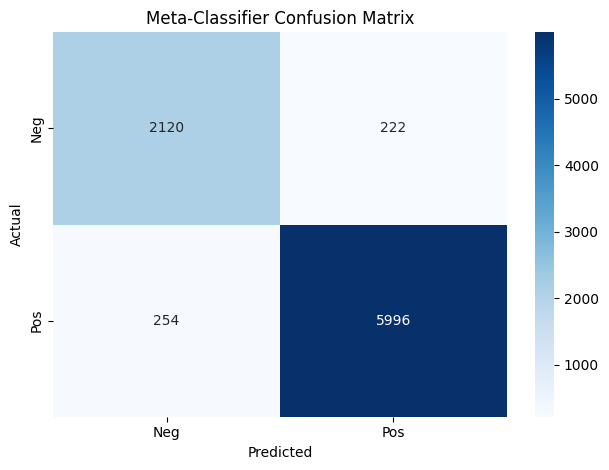

In [26]:
# === Meta-Classifier (Stacked Ensemble) ===
from sklearn.linear_model import LogisticRegression

def get_model_probs(model, loader):
    model.eval()
    all_probs, all_labels = [], []
    with torch.no_grad():
        for batch in loader:
            input_ids, masks, labels = [x.to(device) for x in batch]
            logits = model(input_ids, attention_mask=masks).logits
            probs = torch.softmax(logits, dim=1)
            all_probs.append(probs.cpu())
            all_labels.extend(labels.cpu().numpy())
    return torch.cat(all_probs).numpy(), np.array(all_labels)

bert_val_probs, val_labels = get_model_probs(bert_model, val_loader_b)
roberta_val_probs, _ = get_model_probs(roberta_model, val_loader_r)
X_val = np.hstack((bert_val_probs, roberta_val_probs))

meta_clf = LogisticRegression(max_iter=1000)
meta_clf.fit(X_val, val_labels)

bert_test_probs, test_labels = get_model_probs(bert_model, test_loader_b)
roberta_test_probs, _ = get_model_probs(roberta_model, test_loader_r)
X_test = np.hstack((bert_test_probs, roberta_test_probs))

meta_preds = meta_clf.predict(X_test)

print("\n🔁 Meta-Classifier Ensemble Evaluation")
print(f"Accuracy : {accuracy_score(test_labels, meta_preds):.4f}")
print(classification_report(test_labels, meta_preds, target_names=['Negative', 'Positive']))

# Optional: Confusion Matrix
cm = confusion_matrix(test_labels, meta_preds)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=['Neg', 'Pos'], yticklabels=['Neg', 'Pos'])
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Meta-Classifier Confusion Matrix")
plt.tight_layout()
plt.show()

# 8. Plot metrics

NameError: name 'b_loss' is not defined

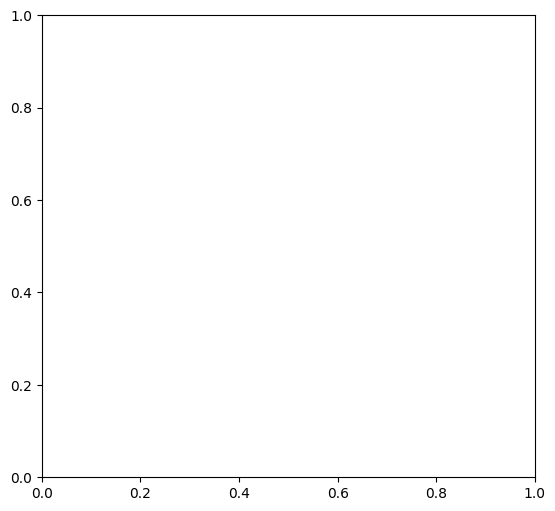

In [28]:
# Plot training curves
plt.figure(figsize=(14,6))
plt.subplot(1,2,1)
plt.plot(b_loss, label='BERT Train')
plt.plot(b_val_loss, label='BERT Val')
plt.plot(r_loss, label='RoBERTa Train')
plt.plot(r_val_loss, label='RoBERTa Val')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Loss over Epochs')
plt.legend()

plt.subplot(1,2,2)
plt.plot(b_acc, label='BERT Train')
plt.plot(b_val_acc, label='BERT Val')
plt.plot(r_acc, label='RoBERTa Train')
plt.plot(r_val_acc, label='RoBERTa Val')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.title('Accuracy over Epochs')
plt.legend()

plt.tight_layout()
plt.savefig("training_val_metrics.png")
plt.show()

# Plot Test Accuracy by Class

In [ ]:
# Calculate per-class test accuracy
classes = ['Negative', 'Positive']
true_labels_arr = np.array(true_labels)
pred_labels_arr = np.array(ensemble_preds)

class_accuracies = []
for label in [0, 1]:
    total = (true_labels_arr == label).sum()
    correct = ((true_labels_arr == label) & (pred_labels_arr == label)).sum()
    acc = correct / total if total > 0 else 0
    class_accuracies.append(acc)

# Plot test accuracy by class
plt.figure(figsize=(6, 5))
sns.barplot(x=classes, y=class_accuracies, palette='pastel')
plt.ylim(0, 1.05)
plt.ylabel("Accuracy")
plt.title("Test Accuracy by Class")
for i, acc in enumerate(class_accuracies):
    plt.text(i, acc + 0.02, f"{acc:.2%}", ha='center', fontsize=12)
plt.tight_layout()
plt.savefig("test_accuracy_by_class.png", dpi=300)
plt.show()

# SHAP

# SHAP EXPLAINABILITY ANALYSIS

In [ ]:
# Robust prediction function for SHAP input
def ensemble_predict_text(inputs):
    if isinstance(inputs, np.ndarray):
        # Convert NumPy object array to list of strings
        texts = [str(x) for x in inputs.tolist()]
    elif isinstance(inputs, list):
        texts = [str(x) for x in inputs]
    else:
        raise ValueError("Unsupported input type for ensemble_predict_text")

    encoded = bert_tokenizer(texts, padding='max_length', truncation=True,
                             max_length=MAX_LEN, return_tensors='pt')
    input_ids = encoded['input_ids'].to(device)
    attention_mask = encoded['attention_mask'].to(device)

    with torch.no_grad():
        b_logits = bert_model(input_ids, attention_mask=attention_mask).logits
        r_logits = roberta_model(input_ids, attention_mask=attention_mask).logits
        probs = (torch.softmax(b_logits, dim=1) + torch.softmax(r_logits, dim=1)) / 2
        return probs.cpu().numpy()

# Use SHAP masker for text
masker = shap.maskers.Text(tokenizer=bert_tokenizer)

# Create SHAP explainer
explainer = shap.Explainer(ensemble_predict_text, masker)

# Sample texts
sample_texts = df['combined_text'].iloc[:100].tolist()

# Generate SHAP values
shap_values = explainer(sample_texts)


# SHAP VISUALIZATIONS

# Global Explanations

# 1. Summary Bar Plot - Overall Feature Importance for ALL CLASSES

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

# Token IDs from input
input_ids = encoded_inputs['input_ids'].cpu().numpy()

# Decode tokens
decoded_tokens = [bert_tokenizer.convert_ids_to_tokens(seq) for seq in input_ids]

# Count average SHAP value per token across samples (global importance)
token_shap_values = {}
for i in range(len(decoded_tokens)):
    for j, token in enumerate(decoded_tokens[i]):
        if j >= shap_values[i].values.shape[0]:
            break  # skip extra tokens beyond SHAP length
        if token not in token_shap_values:
            token_shap_values[token] = []
        token_shap_values[token].append(np.abs(shap_values[i].values[j]).mean())

# Compute mean SHAP value per token
mean_shap = {token: np.mean(vals) for token, vals in token_shap_values.items()}

# Sort and take top 20
sorted_tokens = sorted(mean_shap.items(), key=lambda x: x[1], reverse=True)[:20]
tokens, scores = zip(*sorted_tokens)

# Plot
plt.figure(figsize=(10, 6))
plt.barh(tokens[::-1], scores[::-1])
plt.xlabel("Mean SHAP Value (absolute)")
plt.title("Top 20 Most Influential Words (Global SHAP - All Classes)")
plt.tight_layout()
plt.show()

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from collections import Counter

# STEP 1: Merge subword tokens
def merge_bert_tokens(tokens):
    words = []
    current_word = ""
    for token in tokens:
        if token.startswith("##"):
            current_word += token[2:]
        else:
            if current_word:
                words.append(current_word)
            current_word = token
    if current_word:
        words.append(current_word)
    return words

# STEP 2: Decode tokens and merge
input_ids = encoded_inputs['input_ids'].cpu().numpy()
decoded_tokens = [bert_tokenizer.convert_ids_to_tokens(seq) for seq in input_ids]
merged_token_lists = [merge_bert_tokens(tokens) for tokens in decoded_tokens]

# STEP 3: Compute word-level SHAP values
word_importance = {}
for i in range(len(merged_token_lists)):
    for j, word in enumerate(merged_token_lists[i]):
        if j >= shap_values[i].values.shape[0]:
            continue
        if word not in word_importance:
            word_importance[word] = []
        word_importance[word].append(np.abs(shap_values[i].values[j]).mean())

# STEP 4: Average SHAP values per word
avg_importance = {word: np.mean(vals) for word, vals in word_importance.items() if len(vals) >= 2}
top_words = sorted(avg_importance.items(), key=lambda x: x[1], reverse=True)[:20]

# STEP 5: Plot
tokens, scores = zip(*top_words)
plt.figure(figsize=(10, 6))
plt.barh(tokens[::-1], scores[::-1])
plt.xlabel("Mean SHAP Value (absolute)")
plt.title("Top 20 Most Influential Words (Global SHAP - All Classes)")
plt.tight_layout()
plt.show()

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from collections import Counter, defaultdict

# -------------------------------
# Step 1: Merge BERT subword tokens
# -------------------------------
def merge_bert_tokens(tokens, shap_vals):
    words = []
    word_vals = []
    current_word = ""
    current_vals = []

    for token, val in zip(tokens, shap_vals):
        if token in ["[PAD]", "[CLS]", "[SEP]"]:
            continue
        if token.startswith("##"):
            current_word += token[2:]
            current_vals.append(val)
        else:
            if current_word:
                words.append(current_word)
                word_vals.append(np.mean(current_vals))
            current_word = token
            current_vals = [val]
    if current_word and current_vals:
        words.append(current_word)
        word_vals.append(np.mean(current_vals))

    return words, word_vals

# -------------------------------
# Step 2: Build class-wise token impact
# -------------------------------
class_word_impact = [defaultdict(list) for _ in range(2)]  # 2 classes: 0=Negative, 1=Positive

for i in range(len(shap_values)):
    tokens = bert_tokenizer.convert_ids_to_tokens(encoded_inputs['input_ids'][i])
    
    for class_idx in range(2):
        shap_row_vals = shap_values[i].values[:, class_idx]
        words, vals = merge_bert_tokens(tokens, shap_row_vals)
        
        for w, v in zip(words, vals):
            class_word_impact[class_idx][w].append(v)

# -------------------------------
# Step 3: Average SHAP value per token
# -------------------------------
class_word_avg = [
    {token: np.mean(values) for token, values in class_dict.items()}
    for class_dict in class_word_impact
]

# -------------------------------
# Step 4: Plot bar chart for each class
# -------------------------------
class_names = ['Negative', 'Positive']
for c in range(2):
    avg = class_word_avg[c]
    top_words = sorted(avg.items(), key=lambda x: abs(x[1]), reverse=True)[:20]
    words, shap_vals = zip(*top_words)

    plt.figure(figsize=(10, 5))
    plt.barh(words[::-1], shap_vals[::-1], color='skyblue')
    plt.axvline(0, color='gray', linestyle='--')
    plt.title(f"Top 20 Influential Words Toward '{class_names[c]}' Class")
    plt.xlabel("Mean SHAP Value")
    plt.tight_layout()
    plt.show()

In [ ]:
from collections import defaultdict
import numpy as np
import matplotlib.pyplot as plt

# Class names
class_names = ['Negative', 'Positive']

# Step 1: Decode tokens
input_ids = encoded_inputs['input_ids'].cpu().numpy()
decoded_tokens = [bert_tokenizer.convert_ids_to_tokens(seq) for seq in input_ids]

# Step 2: Initialize SHAP storage per class
class_word_impact = [defaultdict(list) for _ in range(2)]

# Step 3: Fill SHAP values for each token and class
for i in range(len(shap_values.values)):  # samples
    for j, token in enumerate(decoded_tokens[i]):  # tokens
        if token in ['[PAD]', '[CLS]', '[SEP]']:
            continue
        for c in range(2):  # classes: 0 = Negative, 1 = Positive
            try:
                class_word_impact[c][token].append(shap_values.values[i][j, c])
            except IndexError:
                continue  # handle token mismatch if any

# Step 4: Average SHAP value per word per class
class_word_avg = [
    {token: np.mean(contribs) for token, contribs in class_dict.items()}
    for class_dict in class_word_impact
]

# Step 5: Plot top contributors and detractors for each class
for c in range(2):
    word_avg = class_word_avg[c]

    # Support (positive SHAP)
    top_pos = sorted(word_avg.items(), key=lambda x: x[1], reverse=True)[:20]
    words, values = zip(*top_pos)
    plt.figure(figsize=(10, 5))
    plt.barh(words[::-1], values[::-1], color='green')
    plt.title(f"Words Supporting '{class_names[c]}' Class")
    plt.axvline(0, color='gray', linestyle='--')
    plt.xlabel("Mean SHAP Value")
    plt.tight_layout()
    plt.show()

    # Oppose (negative SHAP)
    top_neg = sorted(word_avg.items(), key=lambda x: x[1])[:20]
    words, values = zip(*top_neg)
    plt.figure(figsize=(10, 5))
    plt.barh(words[::-1], values[::-1], color='red')
    plt.title(f"Words Opposing '{class_names[c]}' Class")
    plt.axvline(0, color='gray', linestyle='--')
    plt.xlabel("Mean SHAP Value")
    plt.tight_layout()
    plt.show()

# 2. Summary Plot (Beeswarm)

In [ ]:
# Step 1: Consistent max length
max_len = max([s.values.shape[0] for s in shap_values])
num_samples = len(shap_values)

# Step 2: SHAP values for class 1 (positive), padded
shap_matrix = np.array([
    np.pad(s.values[:, 1], (0, max_len - s.values.shape[0]), constant_values=0)
    for s in shap_values
])

# Step 3: Base values
base_values = np.array([s.base_values[1] for s in shap_values])

# Step 4: Token IDs (already padded/truncated)
input_ids = encoded_inputs['input_ids'].cpu().numpy()

# Step 5: Pad token IDs to match SHAP matrix if needed
if input_ids.shape[1] < max_len:
    pad_width = max_len - input_ids.shape[1]
    input_ids = np.pad(input_ids, ((0, 0), (0, pad_width)), constant_values=0)
elif input_ids.shape[1] > max_len:
    input_ids = input_ids[:, :max_len]

# Step 6: Decode tokens for feature names
decoded_tokens = [bert_tokenizer.convert_ids_to_tokens(seq) for seq in input_ids]
tokens_np = np.array(decoded_tokens)
feature_names = []

for col in tokens_np.T:
    counter = Counter([t for t in col if t not in ['[PAD]', '[CLS]', '[SEP]']])
    feature_names.append(counter.most_common(1)[0][0] if counter else '[PAD]')

# Step 7: Create Explanation object
expl = shap.Explanation(
    values=shap_matrix,
    base_values=base_values,
    data=input_ids,
    feature_names=feature_names
)

# Step 8: Beeswarm Plot
print(" Generating SHAP beeswarm plot with color and labels...")
plt.figure(figsize=(12, 8))
shap.summary_plot(expl, max_display=20, plot_type="dot", show=False)
plt.title("SHAP Beeswarm Plot – Word Impact Toward 'Positive' Class", fontsize=14)
plt.tight_layout()
plt.show()

In [ ]:
# Step 1: Consistent max length
max_len = max([s.values.shape[0] for s in shap_values])
num_samples = len(shap_values)

# Step 2: SHAP values for class 0 (negative), padded
shap_matrix = np.array([
    np.pad(s.values[:, 0], (0, max_len - s.values.shape[0]), constant_values=0)
    for s in shap_values
])

# Step 3: Base values
base_values = np.array([s.base_values[0] for s in shap_values])

# Step 4: Token IDs
input_ids = encoded_inputs['input_ids'].cpu().numpy()

# Step 5: Pad input_ids to match SHAP matrix
if input_ids.shape[1] < max_len:
    pad_width = max_len - input_ids.shape[1]
    input_ids = np.pad(input_ids, ((0, 0), (0, pad_width)), constant_values=0)
elif input_ids.shape[1] > max_len:
    input_ids = input_ids[:, :max_len]

# Step 6: Decode tokens
decoded_tokens = [bert_tokenizer.convert_ids_to_tokens(seq) for seq in input_ids]
tokens_np = np.array(decoded_tokens)
feature_names = []

for col in tokens_np.T:
    counter = Counter([t for t in col if t not in ['[PAD]', '[CLS]', '[SEP]']])
    feature_names.append(counter.most_common(1)[0][0] if counter else '[PAD]')

# Step 7: Create SHAP Explanation
expl = shap.Explanation(
    values=shap_matrix,
    base_values=base_values,
    data=input_ids,
    feature_names=feature_names
)

# Step 8: Beeswarm Plot for Negative Class
print("Generating SHAP beeswarm plot for Negative class...")
plt.figure(figsize=(12, 8))
shap.summary_plot(expl, max_display=20, plot_type="dot", show=False)
plt.title("SHAP Beeswarm Plot – Word Impact Toward 'Negative' Class", fontsize=14)
plt.tight_layout()
plt.show()


In [ ]:
# ===============================
# Step 1: Decode and merge tokens
# ===============================
def merge_bert_tokens(tokens, shap_vals):
    words = []
    word_vals = []
    current_word = ""
    current_vals = []
    
    for token, val in zip(tokens, shap_vals):
        if token in ["[PAD]", "[CLS]", "[SEP]"]:
            continue  # optional: skip special tokens
        if token.startswith("##"):
            current_word += token[2:]
            current_vals.append(val)
        else:
            if current_word:
                words.append(current_word)
                word_vals.append(np.mean(current_vals))
            current_word = token
            current_vals = [val]
    if current_word and current_vals:
        words.append(current_word)
        word_vals.append(np.mean(current_vals))
    
    return words, word_vals

# ===============================
# Step 2: Extract token IDs
# ===============================
input_ids = encoded_inputs['input_ids'].cpu().numpy()
decoded_tokens = [bert_tokenizer.convert_ids_to_tokens(seq) for seq in input_ids]

# ===============================
# Step 3: Merge tokens and SHAP values
# ===============================
all_words, all_shap_vals = [], []
for i in range(len(decoded_tokens)):
    tokens = decoded_tokens[i]
    shap_row_vals = shap_values[i].values[:, 1]  # Class 1 (e.g., Positive)
    words, values = merge_bert_tokens(tokens, shap_row_vals)
    all_words.append(words)
    all_shap_vals.append(values)

# ===============================
# Step 4: Pad all rows to same length
# ===============================
max_len = max(len(seq) for seq in all_words)
padded_words = [seq + ['<pad>'] * (max_len - len(seq)) for seq in all_words]
padded_vals = [vals + [0.0] * (max_len - len(vals)) for vals in all_shap_vals]

# ===============================
# Step 5: Convert to numpy arrays
# ===============================
shap_matrix = np.array(padded_vals)
word_matrix = np.array(padded_words)

# ===============================
# Step 6: Determine feature names
# ===============================
feature_names = []
for col in word_matrix.T:
    counter = Counter(w for w in col if w != '<pad>')
    feature_names.append(counter.most_common(1)[0][0] if counter else '<pad>')

# ===============================
# Step 7: Create SHAP Explanation
# ===============================
expl = shap.Explanation(
    values=shap_matrix,
    base_values=np.mean(shap_values.base_values[:, 1]),
    data=shap_matrix,
    feature_names=feature_names
)

# ===============================
# Step 8: Plot beeswarm
# ===============================
print(" Generating SHAP beeswarm plot with color and labels...")
plt.figure(figsize=(12, 8))
shap.summary_plot(expl, max_display=20, plot_type="dot", show=False)
plt.title("SHAP Beeswarm Plot – Word Impact Toward 'Positive' Class", fontsize=14)
plt.tight_layout()
plt.show()


In [ ]:
# ===============================
# Step 1: Decode and merge tokens
# ===============================
def merge_bert_tokens(tokens, shap_vals):
    words = []
    word_vals = []
    current_word = ""
    current_vals = []
    
    for token, val in zip(tokens, shap_vals):
        if token in ["[PAD]", "[CLS]", "[SEP]"]:
            continue  # optional: skip special tokens
        if token.startswith("##"):
            current_word += token[2:]
            current_vals.append(val)
        else:
            if current_word:
                words.append(current_word)
                word_vals.append(np.mean(current_vals))
            current_word = token
            current_vals = [val]
    if current_word and current_vals:
        words.append(current_word)
        word_vals.append(np.mean(current_vals))
    
    return words, word_vals

# ===============================
# Step 2: Extract token IDs
# ===============================
input_ids = encoded_inputs['input_ids'].cpu().numpy()
decoded_tokens = [bert_tokenizer.convert_ids_to_tokens(seq) for seq in input_ids]

# ===============================
# Step 3: Merge tokens and SHAP values
# ===============================
all_words, all_shap_vals = [], []
for i in range(len(decoded_tokens)):
    tokens = decoded_tokens[i]
    shap_row_vals = shap_values[i].values[:, 0]  # ✅ Class 0 (Negative)
    words, values = merge_bert_tokens(tokens, shap_row_vals)
    all_words.append(words)
    all_shap_vals.append(values)

# ===============================
# Step 4: Pad all rows to same length
# ===============================
max_len = max(len(seq) for seq in all_words)
padded_words = [seq + ['<pad>'] * (max_len - len(seq)) for seq in all_words]
padded_vals = [vals + [0.0] * (max_len - len(vals)) for vals in all_shap_vals]

# ===============================
# Step 5: Convert to numpy arrays
# ===============================
shap_matrix = np.array(padded_vals)
word_matrix = np.array(padded_words)

# ===============================
# Step 6: Determine feature names
# ===============================
feature_names = []
for col in word_matrix.T:
    counter = Counter(w for w in col if w != '<pad>')
    feature_names.append(counter.most_common(1)[0][0] if counter else '<pad>')

# ===============================
# Step 7: Create SHAP Explanation
# ===============================
expl = shap.Explanation(
    values=shap_matrix,
    base_values=np.mean(shap_values.base_values[:, 0]),
    data=shap_matrix,
    feature_names=feature_names
)

# ===============================
# Step 8: Plot beeswarm
# ===============================
plt.close('all')
print("Generating SHAP Beeswarm Plot for Negative class...")
plt.figure(figsize=(12, 8))
shap.summary_plot(expl, max_display=20, plot_type="dot", show=False)
plt.title("SHAP Beeswarm Plot – Word Impact Toward 'Negative' Class", fontsize=14)
plt.tight_layout()
plt.show()


In [ ]:
print("SHAP shape:", shap_values[0].values.shape)  # should be (tokens, 2)
print("Positive sample SHAP avg:", np.mean([s.values[:, 1].mean() for s in shap_values]))
print("Negative sample SHAP avg:", np.mean([s.values[:, 0].mean() for s in shap_values]))


# 3. SHAP Heatmap by Class

In [ ]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# Step 1: Get token IDs
token_ids = encoded_inputs['input_ids'].cpu().numpy()

# Step 2: Decode tokens
decoded_tokens = [bert_tokenizer.convert_ids_to_tokens(seq) for seq in token_ids]

# Step 3: Collect SHAP values by token and class
heatmap_data = {}
for i in range(len(token_ids)):
    for j, token in enumerate(decoded_tokens[i]):
        if token in ['[PAD]', '[CLS]', '[SEP]']:
            continue
        if token not in heatmap_data:
            heatmap_data[token] = [0.0, 0.0]  # class 0 and 1
        for c in range(2):
            heatmap_data[token][c] += shap_values[i].values[j, c]

# Step 4: Normalize SHAP values per token
for token in heatmap_data:
    heatmap_data[token] = [v / len(token_ids) for v in heatmap_data[token]]

# Step 5: Create DataFrame
df_heatmap = pd.DataFrame(heatmap_data).T
df_heatmap.columns = ['Negative', 'Positive']

# Step 6a: Plot top 20 tokens for Positive class
plt.figure(figsize=(12, 8))
sns.heatmap(df_heatmap.sort_values('Positive', ascending=False).head(20), annot=True, cmap="coolwarm")
plt.title("SHAP Token Impact Heatmap (Top 20 by Positive Class)")
plt.tight_layout()
plt.show()

# Step 6b: Plot top 20 tokens for Negative class
plt.figure(figsize=(12, 8))
sns.heatmap(df_heatmap.sort_values('Negative', ascending=False).head(20), annot=True, cmap="coolwarm")
plt.title("SHAP Token Impact Heatmap (Top 20 by Negative Class)")
plt.tight_layout()
plt.show()


In [ ]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from collections import defaultdict

# Step 1: Decode and merge subword tokens
def merge_bert_tokens(tokens, shap_vals):
    merged_tokens = []
    merged_vals = []
    current_token = ""
    current_val = []

    for token, val in zip(tokens, shap_vals):
        if token in ["[PAD]", "[CLS]", "[SEP]"]:
            continue
        if token.startswith("##"):
            current_token += token[2:]
            current_val.append(val)
        else:
            if current_token:
                merged_tokens.append(current_token)
                merged_vals.append(np.mean(current_val, axis=0))
            current_token = token
            current_val = [val]
    if current_token:
        merged_tokens.append(current_token)
        merged_vals.append(np.mean(current_val, axis=0))
    
    return merged_tokens, merged_vals

# Step 2: Decode tokens
token_ids = encoded_inputs['input_ids'].cpu().numpy()
decoded_tokens_batch = [bert_tokenizer.convert_ids_to_tokens(seq) for seq in token_ids]

# Step 3: Collect and merge SHAP values
token_shap_by_class = defaultdict(lambda: [0.0, 0.0])
token_counts = defaultdict(int)

for i in range(len(token_ids)):
    tokens = decoded_tokens_batch[i]
    shap_vals = shap_values[i].values  # shape (seq_len, 2)
    merged_tokens, merged_vals = merge_bert_tokens(tokens, shap_vals.tolist())
    
    for tok, val in zip(merged_tokens, merged_vals):
        token_shap_by_class[tok][0] += val[0]
        token_shap_by_class[tok][1] += val[1]
        token_counts[tok] += 1

# Step 4: Normalize SHAP values by frequency
for token in token_shap_by_class:
    count = token_counts[token]
    token_shap_by_class[token] = [v / count for v in token_shap_by_class[token]]

# Step 5: Build DataFrame
df_tokens = pd.DataFrame(token_shap_by_class).T
df_tokens.columns = ['Negative', 'Positive']

# Step 6: Sort by total absolute impact and display top 20
df_tokens['abs_max'] = df_tokens.abs().max(axis=1)
df_top = df_tokens.sort_values('abs_max', ascending=False).drop(columns='abs_max').head(20)

# Step 7: Plot heatmap for both classes
plt.figure(figsize=(12, 8))
sns.heatmap(df_top, annot=True, cmap="coolwarm", center=0)
plt.title("SHAP Token Impact Heatmap (Top 20 Merged Tokens by Class)")
plt.tight_layout()
plt.show()


# Local Explanations

# 3. Force Plots


In [ ]:
print("\nGenerating Force Plots for Sample Predictions")

for i in range(3):
    sample = shap_values[i]
    input_slice = {k: v[i:i+1].to(device) for k, v in encoded_inputs.items()}
    pred_class = np.argmax(ensemble_predict(input_slice)[0])

    # Get original tokens
    token_ids = encoded_inputs['input_ids'][i]
    tokens = bert_tokenizer.convert_ids_to_tokens(token_ids)
    
    # Filter out special tokens
    filtered_tokens = []
    filtered_values = []

    for token, val in zip(tokens, sample.values[:, pred_class]):
        if token not in ["[PAD]", "[CLS]", "[SEP]"]:
            filtered_tokens.append(token)
            filtered_values.append(val)

    # Make sure lengths match
    if len(filtered_tokens) != len(filtered_values):
        print(f"❌ Skipping sample {i} due to token mismatch")
        continue

    # Plot
    shap.plots.text(shap.Explanation(
        values=np.array(filtered_values),
        base_values=sample.base_values[pred_class],
        data=filtered_tokens
    ))


In [ ]:
def merge_tokens_and_shap(tokens, values):
    merged_tokens = []
    merged_values = []
    current_token = ""
    current_values = []

    for token, value in zip(tokens, values):
        if token.startswith("##"):
            current_token += token[2:]
            current_values.append(value)
        else:
            if current_token:
                merged_tokens.append(current_token)
                merged_values.append(np.sum(current_values))
            current_token = token
            current_values = [value]
    if current_token:
        merged_tokens.append(current_token)
        merged_values.append(np.sum(current_values))

    return merged_tokens, merged_values

filtered_tokens = []
filtered_values = []

for token, val in zip(tokens, sample.values[:, pred_class]):
    if token not in ["[PAD]", "[CLS]", "[SEP]"]:
        filtered_tokens.append(token)
        filtered_values.append(val)

# Merge subword tokens
merged_tokens, merged_values = merge_tokens_and_shap(filtered_tokens, filtered_values)

shap.plots.text(shap.Explanation(
    values=np.array(merged_values),
    base_values=sample.base_values[pred_class],
    data=merged_tokens
))


In [ ]:
from transformers import BertTokenizer
import shap
import numpy as np

print("\n🔄 Generating SHAP Force Plots (Merged Tokens) for Sample Predictions")

# Loop over desired samples
for i in range(3):  # Change this range as needed
    sample = shap_values[i]

    for class_idx, class_label in enumerate(["Negative", "Positive"]):
        print(f"\n🔍 Force plot for class: {class_label}")

        # Step 1: Get raw tokens
        input_ids = encoded_inputs['input_ids'][i].cpu().numpy()
        tokens = bert_tokenizer.convert_ids_to_tokens(input_ids, skip_special_tokens=True)

        # Step 2: Get SHAP values
        token_shap_vals = sample.values[:, class_idx]

        # Step 3: Merge subwords
        merged_tokens = []
        merged_values = []

        current_token = ""
        current_vals = []

        for token, val in zip(tokens, token_shap_vals):
            if token.startswith("##"):
                current_token += token[2:]
                current_vals.append(val)
            else:
                if current_token:
                    merged_tokens.append(current_token)
                    merged_values.append(np.mean(current_vals))
                current_token = token
                current_vals = [val]

        # Add last token
        if current_token:
            merged_tokens.append(current_token)
            merged_values.append(np.mean(current_vals))

        # Step 4: Create SHAP Explanation for text plot
        expl = shap.Explanation(
            values=np.array(merged_values),
            base_values=sample.base_values[class_idx],
            data=merged_tokens
        )

        # Step 5: Show plot
        shap.plots.text(expl)

In [ ]:
# Print the first 5 raw text samples used in SHAP
print("🔍 First 5 SHAP Sample Texts:")
for i, text in enumerate(sample_texts[:5]):
    print(f"\nSample {i+1}:")
    print(text)

# 4. Waterfall Plots

In [ ]:
print("\nGenerating Waterfall Plots for Two Examples")
for i in [0, 1]:
    sample = shap_values[i]
    
    # Run prediction on the current sample
    input_slice = {k: v[i:i+1].to(device) for k, v in encoded_inputs.items()}
    pred_class = np.argmax(ensemble_predict(input_slice)[0])

    # Decode tokens
    tokens = bert_tokenizer.convert_ids_to_tokens(encoded_inputs['input_ids'][i])

    # Construct SHAP explanation
    explanation = shap.Explanation(
        values=sample.values[:, pred_class],
        base_values=sample.base_values[pred_class],
        data=tokens,
        feature_names=tokens
    )

    # Plot waterfall
    shap.plots.waterfall(explanation, max_display=20)
